In [7]:
import pandas as pd
import thebeat
import os
import matplotlib.pyplot as plt

In [8]:
# Load ITIs df
ITIs = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs.csv'))
ITIs_bytrial = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs_bytrial.csv'))
pp_measures = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'pp_measures.csv'))

In [9]:
# Find sequence id's of trials with highest and lowest entropy difference
highest_G = ITIs_bytrial.nlargest(18, 'G_resp').sequence_id.values
middle_G_a = len(ITIs_bytrial) // 2 - 9
middle_G_b = len(ITIs_bytrial) // 2 + 9
middle_G = ITIs_bytrial.sort_values(by='G_resp').iloc[middle_G_a:middle_G_b].sequence_id.values
lowest_G = ITIs_bytrial.nsmallest(18, 'G_resp').sequence_id.values

# Get ITIs of 9 sequences with the highest entropy difference
highest_G_df = ITIs[ITIs['sequence_id'].isin(highest_G)]
middle_G_df = ITIs[ITIs['sequence_id'].isin(middle_G)]
lowest_G_df = ITIs[ITIs['sequence_id'].isin(lowest_G)]

# Lowest G

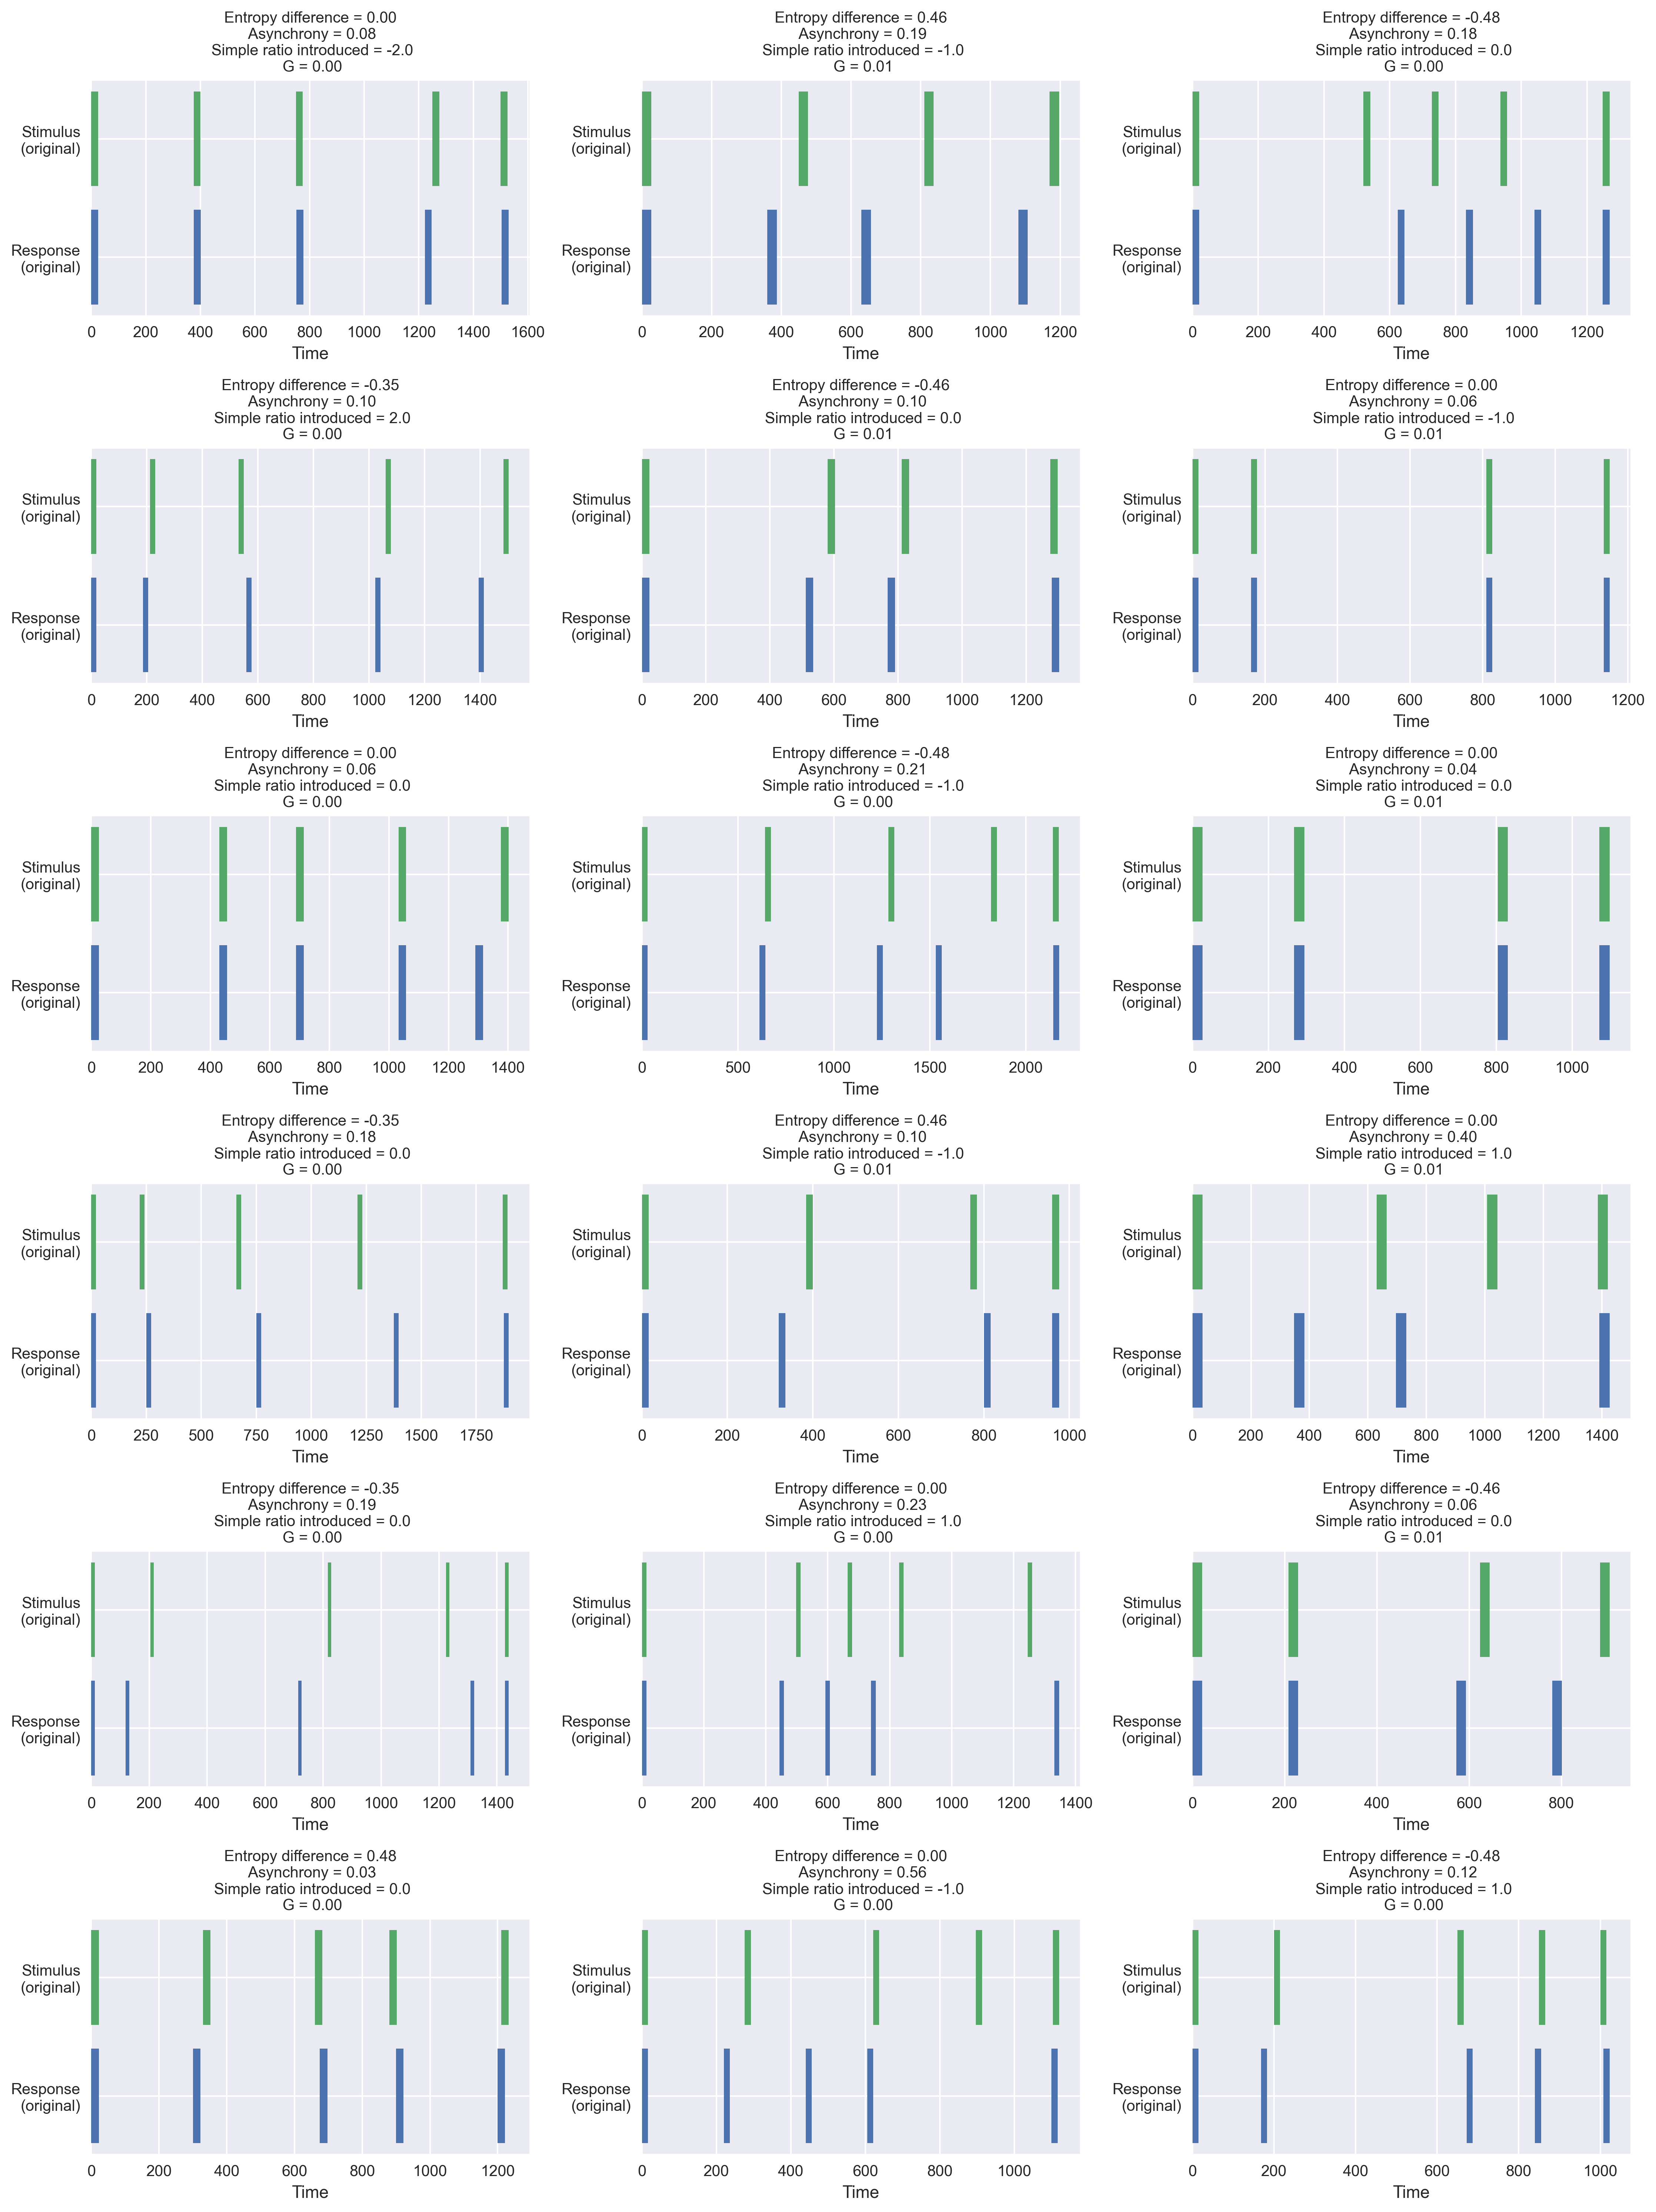

In [10]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(6, 3, figsize=(15, 20), tight_layout=True, dpi=300)

count = 0

for seq_id, seq_df in lowest_G_df.groupby('sequence_id'):
    resp = thebeat.Sequence(seq_df.resp_iti_norm_q.values)
    stim = thebeat.Sequence(seq_df.stim_ioi_q.values)
    thebeat.visualization.plot_multiple_sequences([stim, resp], y_axis_labels=['Stimulus\n(original)', 'Response\n(original)'],
                                                  ax = axs.flat[count],
    title=f"Entropy difference = {seq_df.entropy_diff.values[0]:.2f}\n \
Asynchrony = {ITIs_bytrial[ITIs_bytrial.sequence_id == seq_id].asynchrony_norm_abs_trialsum.values[0]:.2f}\n \
Simple ratio introduced = {seq_df.simple_ratio_introduced.values[0]}\n \
G = {seq_df.G_resp.values[0]:.2f}")
    

    count += 1

# Change font size of title in all subplots
for ax in axs.flat:
    ax.title.set_fontsize(10)

# Middle G

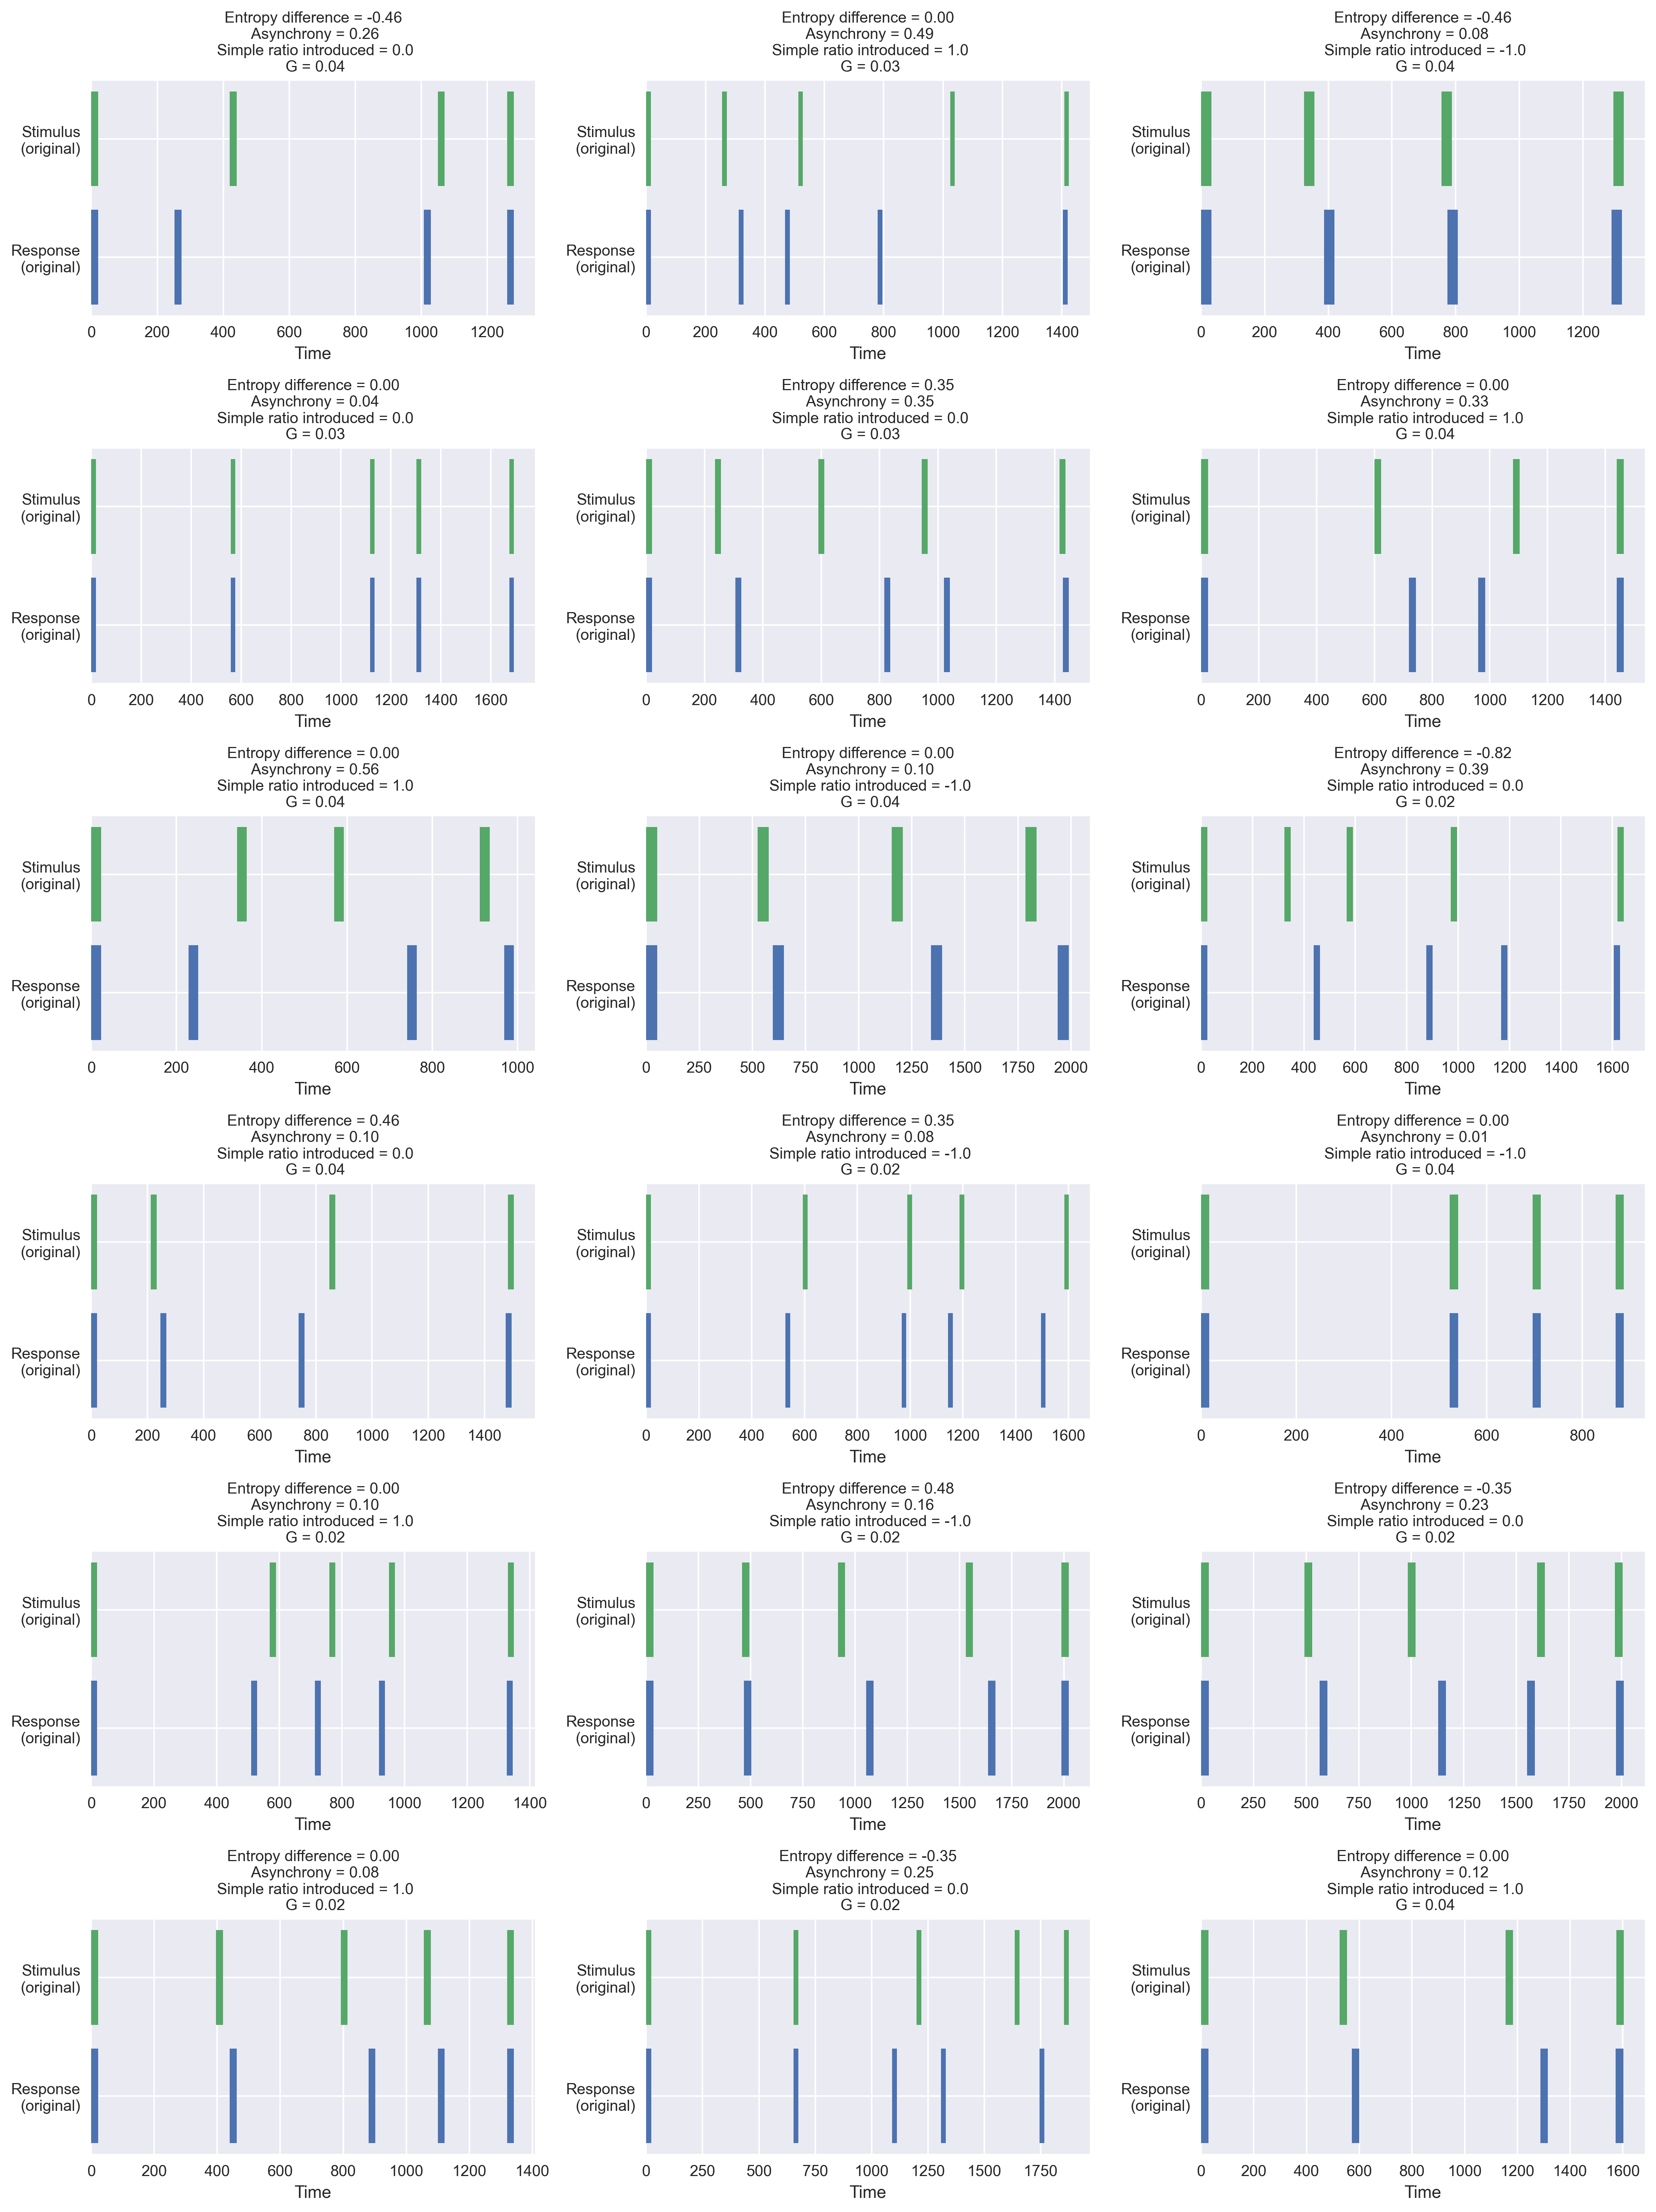

In [11]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(6, 3, figsize=(15, 20), tight_layout=True, dpi=300)

count = 0

for seq_id, seq_df in middle_G_df.groupby('sequence_id'):
    resp = thebeat.Sequence(seq_df.resp_iti_norm_q.values)
    stim = thebeat.Sequence(seq_df.stim_ioi_q.values)
    thebeat.visualization.plot_multiple_sequences([stim, resp], y_axis_labels=['Stimulus\n(original)', 'Response\n(original)'],
                                                  ax = axs.flat[count],
    title=f"Entropy difference = {seq_df.entropy_diff.values[0]:.2f}\n \
Asynchrony = {ITIs_bytrial[ITIs_bytrial.sequence_id == seq_id].asynchrony_norm_abs_trialsum.values[0]:.2f}\n \
Simple ratio introduced = {seq_df.simple_ratio_introduced.values[0]}\n \
G = {seq_df.G_resp.values[0]:.2f}")
    

    count += 1

# Change font size of title in all subplots
for ax in axs.flat:
    ax.title.set_fontsize(10)

# Highest G

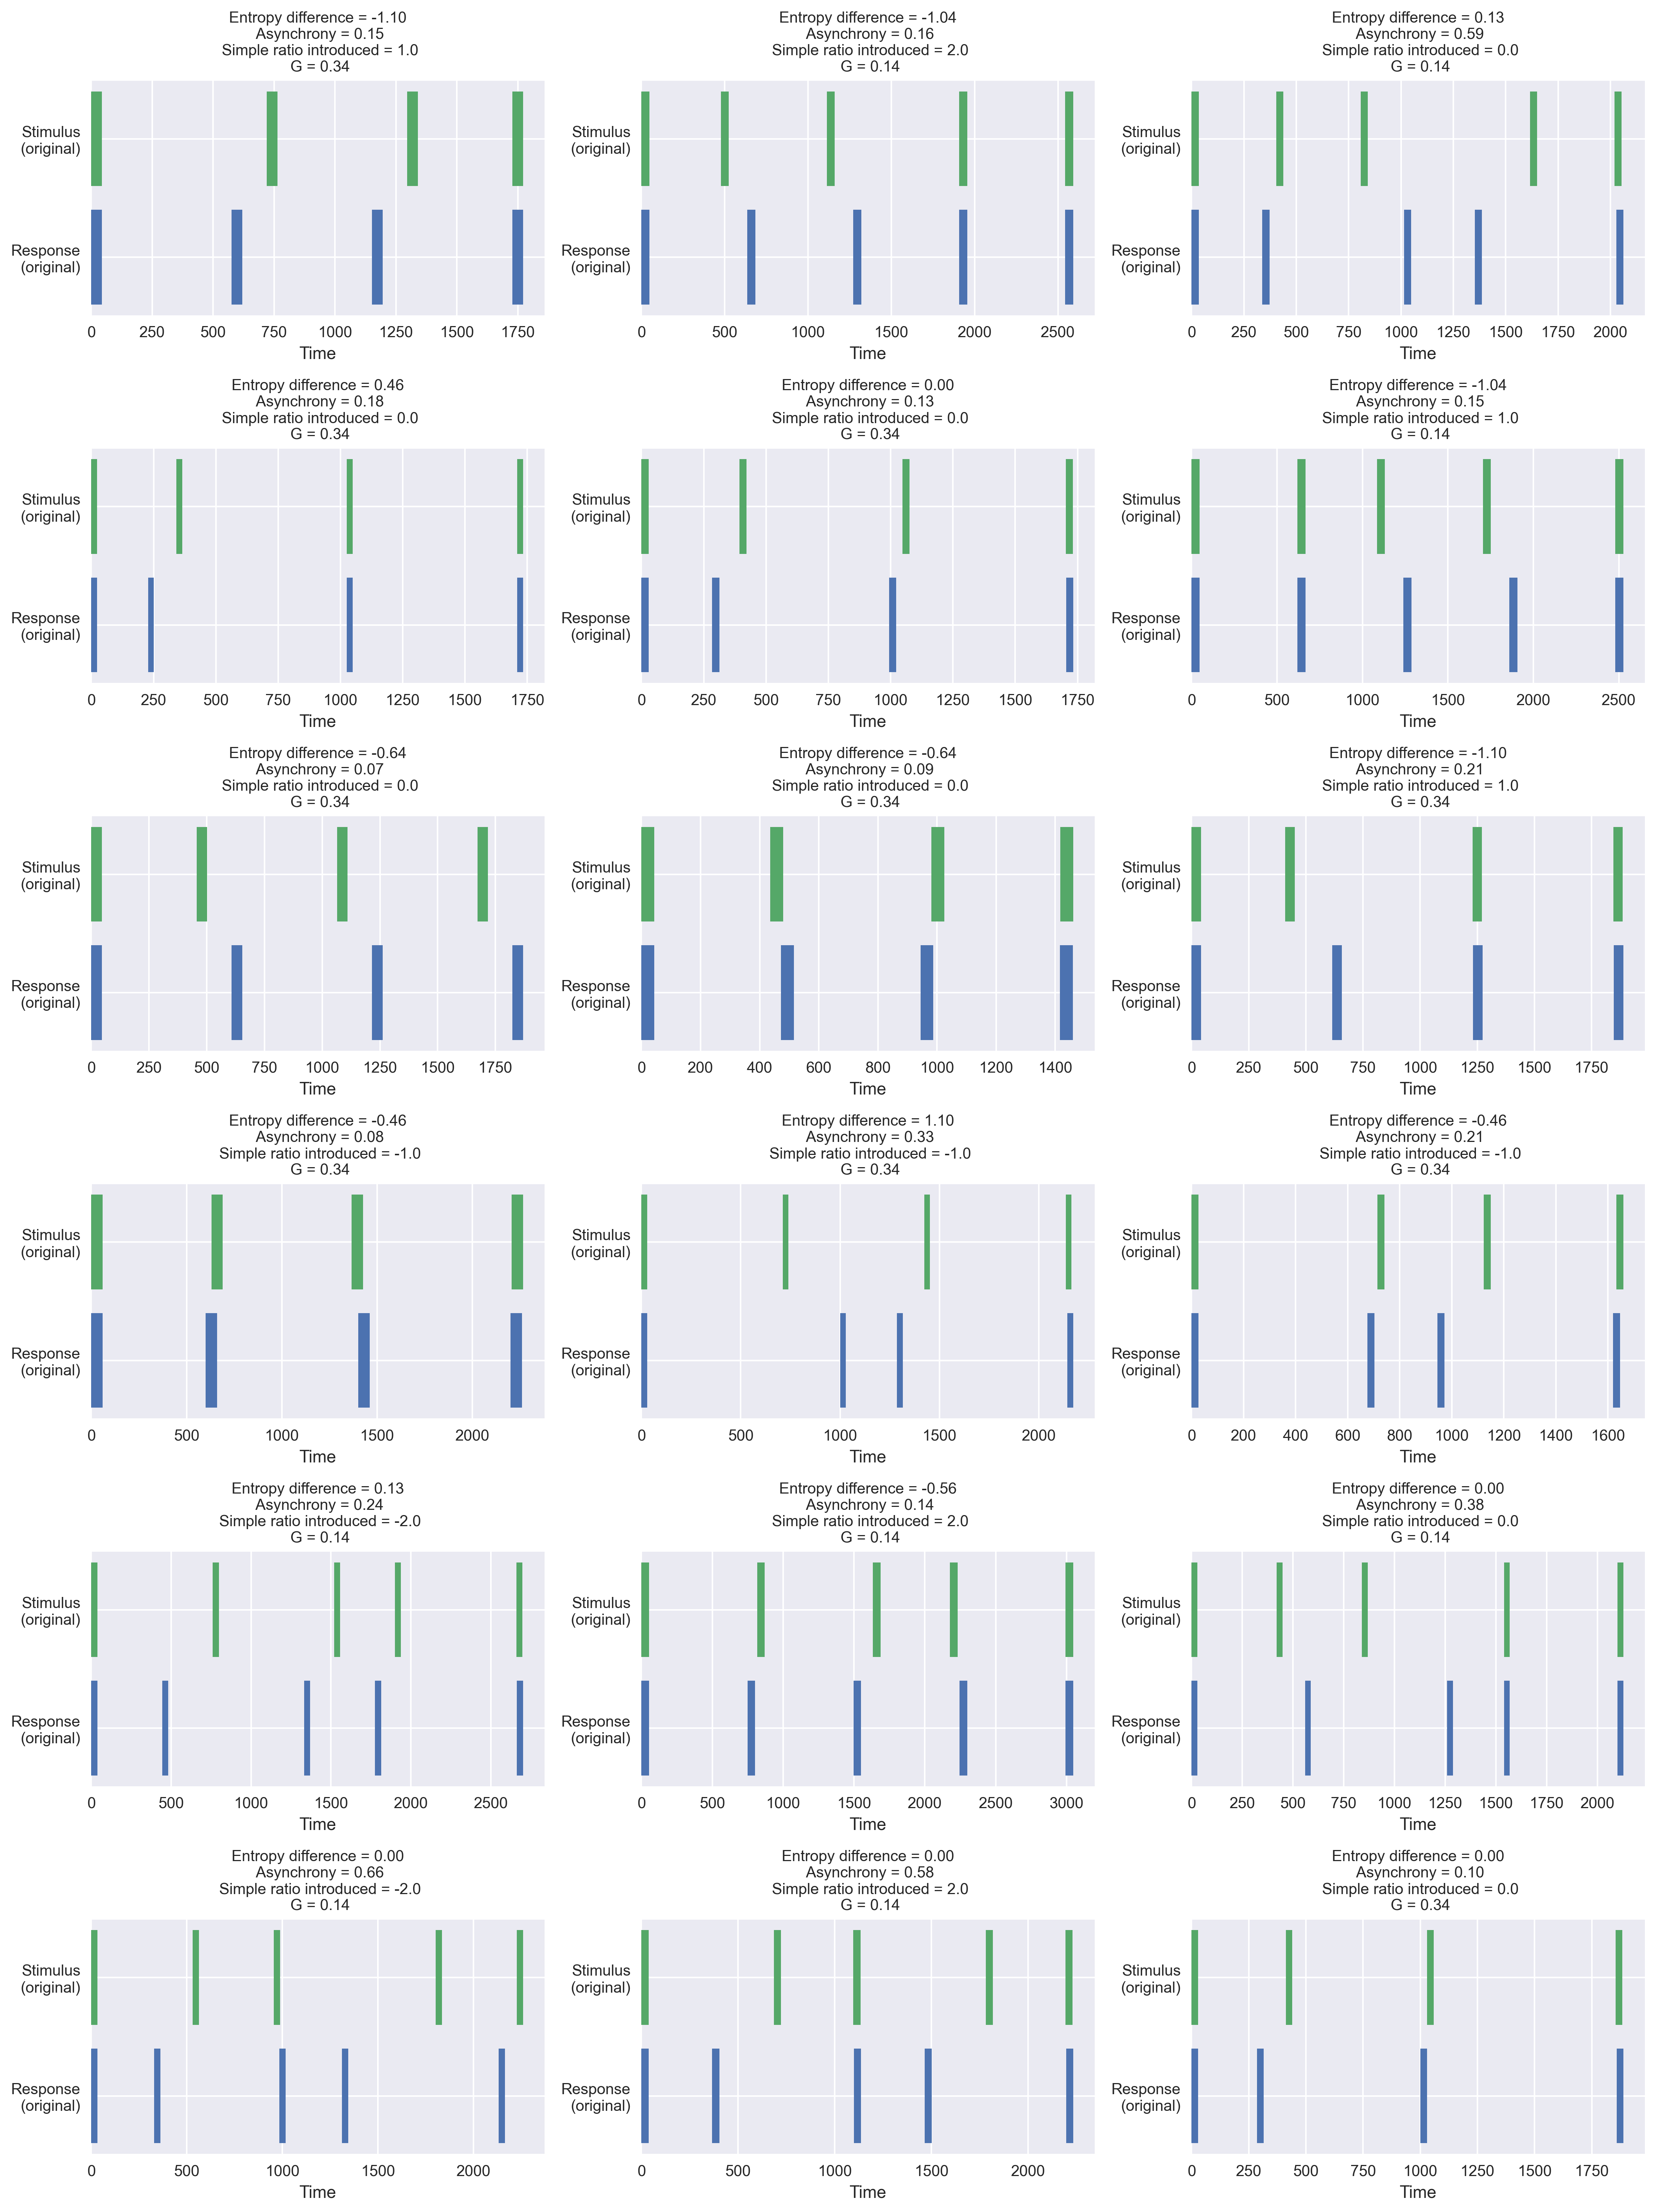

In [12]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(6, 3, figsize=(15, 20), tight_layout=True, dpi=300)

count = 0

for seq_id, seq_df in highest_G_df.groupby('sequence_id'):
    resp = thebeat.Sequence(seq_df.resp_iti_norm_q.values)
    stim = thebeat.Sequence(seq_df.stim_ioi_q.values)
    thebeat.visualization.plot_multiple_sequences([stim, resp], y_axis_labels=['Stimulus\n(original)', 'Response\n(original)'],
                                                  ax = axs.flat[count],
    title=f"Entropy difference = {seq_df.entropy_diff.values[0]:.2f}\n \
Asynchrony = {ITIs_bytrial[ITIs_bytrial.sequence_id == seq_id].asynchrony_norm_abs_trialsum.values[0]:.2f}\n \
Simple ratio introduced = {seq_df.simple_ratio_introduced.values[0]}\n \
G = {seq_df.G_resp.values[0]:.2f}")
    

    count += 1

# Change font size of title in all subplots
for ax in axs.flat:
    ax.title.set_fontsize(10)